# 使用光谱指数特征训练传统机器学习模型

**目标**: 
该脚本将使用 `spectral_index_preprocessing.ipynb` 生成的特征文件，训练一个随机森林分类器，并评估其性能，以便与深度学习模型进行直接比较。

**核心步骤**:
1.  加载 `train_features.csv` 和 `test_features.csv`。
2.  准备训练和测试数据 (X_train, y_train, X_test, y_test)。
3.  训练一个随机森林分类器。
4.  在测试集上进行预测并生成详细的分类报告和混淆矩阵。

In [1]:
# 导入必要的库
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

# 从 scikit-learn 导入模型和评估工具
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

## 1. 配置路径并加载数据

确保此路径指向包含 `_features.csv` 文件的 `split_info` 文件夹。

In [2]:
# --- 关键配置区 ---
# project_path = "F:/vscode project/IMA_PW3/EuroSat_classification-main_data_wx/"
project_path ="F:/vscode project/IMA_PW3/data"
metadata_path = os.path.join(project_path, "split_info/").replace('\\', '/')

print(f"将从 '{metadata_path}' 路径加载特征文件...")

# --- 加载带有特征的CSV文件 ---
try:
    train_df = pd.read_csv(os.path.join(metadata_path, 'train_features.csv'))
    test_df = pd.read_csv(os.path.join(metadata_path, 'test_features.csv'))
    # 验证集在这里可以不用，因为我们主要是在测试集上做最终评估
except FileNotFoundError as e:
    print(f"错误: {e}\n请确保您已经运行了 spectral_index_preprocessing.ipynb 脚本。")
    raise

# 加载标签映射，用于后续的可视化
with open(os.path.join(metadata_path, 'label_map.json'), 'r') as f:
    label_to_index = json.load(f)
index_to_label = {v: k for k, v in label_to_index.items()}
class_names = list(label_to_index.keys()) # 获取类别名称列表

print("\n数据加载完成！")
print(f"训练样本数: {len(train_df)}")
print(f"测试样本数: {len(test_df)}")

将从 'F:/vscode project/IMA_PW3/data/split_info/' 路径加载特征文件...

数据加载完成！
训练样本数: 18899
测试样本数: 4050


## 2. 准备训练和测试数据

我们需要将数据分为特征 `(X)` 和目标标签 `(y)`。

In [3]:
# 定义我们的特征列
feature_columns = ['NDVI_mean', 'NDWI_mean', 'NDBI_mean']

# 准备训练数据
X_train = train_df[feature_columns]
y_train = train_df['Label']

# 准备测试数据
X_test = test_df[feature_columns]
y_test = test_df['Label']

print("特征 (X_train) 的前5行:")
display(X_train.head())
print("\n标签 (y_train) 的前5行:")
display(y_train.head())

特征 (X_train) 的前5行:


,NDVI_mean,NDWI_mean,NDBI_mean
0,0.789850,-0.648776,-0.381513
1,0.545290,-0.382639,-0.266399
2,0.528772,-0.489389,-0.079064
3,0.503885,-0.476215,-0.180113
4,0.475804,-0.396860,-0.122317



标签 (y_train) 的前5行:


0    1
1    5
2    6
3    0
4    7
Name: Label, dtype: int64

## 3. 训练随机森林分类器

In [4]:
# 初始化随机森林分类器
# n_estimators 是森林中树的数量，可以调整
# random_state 保证每次训练结果一致
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 使用所有CPU核心

print("开始训练随机森林模型...")
# 使用训练数据来训练（拟合）模型
rf_classifier.fit(X_train, y_train)

print("模型训练完成！")

开始训练随机森林模型...
模型训练完成！


## 4. 在测试集上评估模型性能

In [5]:
# --- 步骤 1: 进行预测 ---
y_pred = rf_classifier.predict(X_test)

# --- 步骤 2: 计算并打印总体准确率 ---
accuracy = accuracy_score(y_test, y_pred)
print(f"随机森林分类器的总体准确率 (Accuracy): {accuracy:.4f}")

# --- 步骤 3: 生成并打印详细的分类报告 ---
# 这个报告包含了每个类别的 Precision, Recall, F1-score
print("\n--- 分类报告 ---")
report = classification_report(y_test, y_pred, target_names=class_names)
print(report)

随机森林分类器的总体准确率 (Accuracy): 0.6336

--- 分类报告 ---
                      precision    recall  f1-score   support

          AnnualCrop       0.59      0.56      0.57       450
              Forest       0.77      0.87      0.82       450
HerbaceousVegetation       0.59      0.59      0.59       450
             Highway       0.39      0.29      0.33       375
          Industrial       0.63      0.73      0.67       375
             Pasture       0.54      0.45      0.49       300
       PermanentCrop       0.49      0.48      0.48       375
         Residential       0.48      0.54      0.51       450
               River       0.74      0.73      0.74       375
             SeaLake       0.99      0.99      0.99       450

            accuracy                           0.63      4050
           macro avg       0.62      0.62      0.62      4050
        weighted avg       0.63      0.63      0.63      4050



## 5. 可视化混淆矩阵

混淆矩阵可以清晰地展示模型在哪些类别上表现好，在哪些类别上容易混淆。

c:\Users\Administrator\anaconda\envs\pytorch\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Administrator\anaconda\envs\pytorch\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Administrator\anaconda\envs\pytorch\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Administrator\anaconda\envs\pytorch\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 31614 (\N{CJK UNIFIED IDEOGRAPH-7B7E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Administrator\anaconda\envs\pytorch\lib\site-packages\IPython\core\pylabtoo

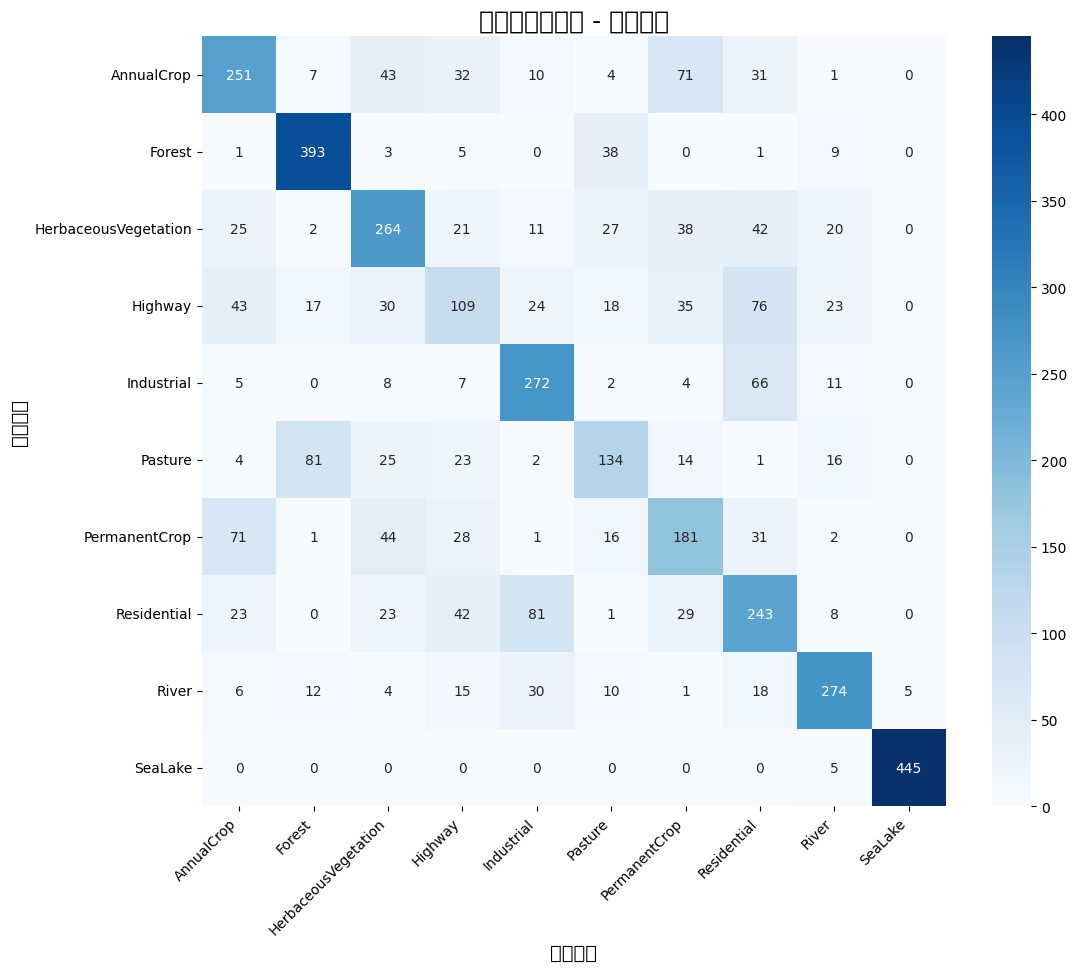

In [6]:
# 计算混淆矩阵
cm = confusion_matrix(y_test, y_pred)

# 使用 seaborn 绘制热力图
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)

# 美化图表
plt.title('随机森林分类器 - 混淆矩阵', fontsize=18)
plt.xlabel('预测标签', fontsize=14)
plt.ylabel('真实标签', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

### 结果对比

现在，您可以将这个脚本输出的**总体准确率**和**分类报告**与您 `EuroSat_ResNeXt_Classifier.ipynb` 中 `evaluate_test_set` 函数输出的结果进行直接比较。

由于我们使用了完全相同的数据划分，所以这个对比是**公平且有意义的**。通过比较，您就可以清晰地看到，是深度学习模型自动学习的特征更有效，还是我们手动设计的这几个光谱指数特征更胜一筹。